# Data Analysis and Processing Notebook

Project : Accessibility and quality of emergency medical services under decentralization policy

Author : P. Sitthirat et al.

This notebook serves as a comprehensive guide for processing and analyzing the impact of the decentralization policy on emergency medical services. It includes data cleaning, manipulation, and analysis.

Objectives:
- Processing the national database on EMS.
- Evaluating the accessibility and quality of EMS before and after decentralization.
- Identifying key metrics and trends in EMS performance.
- Conducting statistical and time series analyses to assess policy impact.

Requirements: Ensure the following libraries are installed before running the notebook: `pip install -r scripts/requirements.txt`

## Overview

This notebook is structured into several key sections:
- **Data Loading and Preprocessing**: Importing and cleaning the ITEMS database for analysis.
- **Descriptive Statistical Analysis**: Summarizing key demographic and operational metrics.
- **Comparative Analysis** Examining differences in EMS performance metrics between decentralized and non-decentralized provinces.
- **Time Series Analysis**: Assessing temporal trends before and after decentralization.
- **Logistic Regression Analysis**: Evaluating factors influencing survival outcomes.
- **Visualization**: Presenting results through graphs and tables.
- **Output**: Saving processed data and results for further use.

## 1. Initial Setup and Library Imports

This cell initializes the notebook with necessary configurations and imports key libraries and custom modules for data processing, analysis, and visualization.

### Features:
1. **IPython Extensions**:
- `%load_ext autoreload`: Automatically reloads modules before executing cells, ensuring the latest code changes are applied.
- `%autoreload 2`: Reloads all imported modules every time a cell is executed.

2. **Library Imports**:
- `pandas`: For data manipulation and analysis.
- `numpy`: For numerical operations.
- `warnings`: To handle and suppress warnings.
- `matplotlib`: For visualization

3. **Custom Modules** from scripts folder:
- `process`: For data cleaning and processing.
- `skim`: For assessing data quality.
- `analyse`: For performing data analysis.
- `graph`: For creating visualizations.

4. **Notebook Settings**:
- `pd.set_option('future.no_silent_downcasting', True)`: Ensures that pandas raises warnings for downcasting operations.
- `warnings.simplefilter('ignore', FutureWarning)`: Suppresses future warnings for a cleaner output.
- `warnings.simplefilter('ignore', SyntaxWarning)`: Suppresses syntax warnings for a cleaner output.
- `warnings.simplefilter('ignore', DeprecationWarning)`: Suppresses deprecation warnings for a cleaner output.
- `pd.options.display.max_columns = None`: Displays all columns in pandas DataFrames for better visibility.

### Code:
This configuration ensures an efficient and clean working environment for data analysis and processing.

In [163]:
%load_ext autoreload
%autoreload 2

# Import library
import pandas as pd
import numpy as np
import warnings
import textwrap
import math
import seaborn as sns
import matplotlib.pyplot as plt
from scripts import process
from scripts import skim
from scripts import imputation
from scripts import analyse

from IPython.display import clear_output
pd.set_option('future.no_silent_downcasting', True)
warnings.simplefilter('ignore', FutureWarning)
warnings.simplefilter('ignore', SyntaxWarning)
warnings.simplefilter('ignore', DeprecationWarning)
pd.options.display.max_columns = None

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 2. Import, Clean, and Manipulate the Dataset

## 2.1 Hospital/Facilities Data

The dataset is extracted from hospital registry of Office for Permanent Secretary of Ministry of Public Health

In [2]:
# Import hospital data
data_dir = 'data/RESOURCE'
file_name = 'hosp'
output_dir = 'output'

hos, _, _ = process.DataCleaning.clean(file_name, data_dir, output_dir, export_df=False)

File name                : hosp
Path to data dictionary  : data/RESOURCE/data_dict-hosp.xlsx
Path to cleaned dataset  : None


In [14]:
df = hos.copy()

df['hcode'] = df['hcode'].apply(lambda x: str(x)[2:7] if pd.notna(x) else None)
df = df.rename(columns={'hcode': 'hosp_code', 'hname': 'hosp'})
df[['hosp', 'hosp_code']].to_csv('output/map/map_hosp-hosp_code.csv')

## 2.2 The National Level Data
The dataset is extracted from the Information Technology for Emergency Medical Services (ITEMS) database, It spans two fiscal years (October 2021 to September 2023) and is divided into two sources:
- ITEMS: Data from October 2021 to November 2022.
- ITEMS 4.0: Data from December 2022 to September 2023.

### 2.2.1 ITEMS
The objective here is to process and prepare the data from the ITEMS system for analysis. This involves cleaning, creating derived variables, and validating the data through the following steps:
1. **Data Import and Initial Cleaning** 
   - Load and clean the raw data using the custom `process.DataCleaning` module.
   - Generate a data dictionary in the `data/ITEMS/OVERALL` folder to understand variable types and mappings.
   - Update column names based on a validation dictionary for standardization.
   - Validate and convert column data types, correcting errors as needed. All corrections are documented in the `output/errors` folder, which includes the 'error' data points and their 'edited' versions.
   - Remove 1,101 duplicate rows to ensure data consistency. 
2. **Filter the 'Cardiac Arrest' data**: for more efficient cleaning and transformation
3. **Further Cleaning and Transformation**: After the initial cleaning, additional steps were performed:
   - **Calculate Duration Metrics**: Generate key time metrics to measure EMS performance:
      - **Dispatch time** (`dur_dispatch`): Time from the emergency call to dispatch command.
      - **Activation time** (`dur_activation`): Time from dispatch command to ambulance departure.
      - **Response time** (`dur_response`): Time from the call to ambulance arrival at the scene.
      - **Scene time** (`dur_scene`): Time spent at the scene before leaving for the hospital.
      - **Transport time** (`dur_transport`): Time from leaving the scene to arriving at the hospital.
      - **Prehospital time** (`dur_prehos`): Time from the call to arrival at the emergency department.
   - **Handling Missing Data**: Fill missing values for provinces and hospitals using related columns for reference.
   - **Categorical Data Mapping**: Translate and group categorical variables using mapping files stored in `output/map`.
   - **Numerical Data Validation**: Mark values exceeding the 99th percentile as null to handle outliers.
   - **Outcome Validation (`dead`)**:
      - Mark a patient as deceased if 
         - declared dead at the scene (`result_op`) and any outcome at the emergency department.
         - at the emergency department (`result_hos`) with any outcome (not dead) or null at the scene.
      - Mark a patient as survived if explicitly indicated as survived in either operation or ED records.
      - Leave the outcome as "none" if both `result_op` and `result_hos` are unavailable.
   - **Performance Grouping**: Categorize performance metrics based on these benchmarks:
      - Dispatch time < 1 minute.
      - Activation time < 2 minutes.
      - Response time < 8 minutes.

Finally, the DataFrame will be saved as `df_items` for further analysis.

In [471]:
# Import ITEMS Oct 2021 - Nov 2022
data_dir = 'data/ITEMS/OVERALL'
file_name = 'ITEMS_202110-202211'
output_dir = 'output'

df_forclean, df_raw, dict_path = process.DataCleaning.clean(file_name, data_dir, output_dir, export_df=False)

File name                : ITEMS_202110-202211
Path to data dictionary  : data/ITEMS/OVERALL/data_dict-ITEMS_202110-202211.xlsx
Path to cleaned dataset  : None


In [472]:
## Adding the calculated columns

df = df_forclean.copy()

# Fill null scene departure time with hospital time
start = pd.to_datetime('2021-10-01')
end = pd.to_datetime('2022-11-30')
for time_col in ['date', 'time', 'time_call', 'time_dispatch', 'time_outbase', 'time_arrive', 'time_scenedept', 'time_hosp', 'time_basereturn']:
    df[time_col] = df[time_col].apply(lambda x: x if start <= x <= end else None)
df['time_scenedept'] = df['time_scenedept'].fillna(df['time_hosp'])

# Create the duration parameters
df['dur_dispatch'] = df.apply(lambda row: (row['time_dispatch'] - row['time_call']).total_seconds() / 60, axis=1)
df['dur_activation'] = df.apply(lambda row: (row['time_outbase'] - row['time_dispatch']).total_seconds() / 60, axis=1)
df['dur_response'] = df.apply(lambda row: (row['time_arrive'] - row['time_call']).total_seconds() / 60, axis=1)
df['dur_scene'] = df.apply(lambda row: (row['time_scenedept'] - row['time_arrive']).total_seconds() / 60, axis=1)
df['dur_transport'] = df.apply(lambda row: (row['time_hosp'] - row['time_scenedept']).total_seconds() / 60, axis=1)
df['dur_prehos'] = df.apply(lambda row: row['dur_response']+row['dur_scene']+row['dur_transport'], axis=1)

# Create province and hospital data columns
df['prov'] = df['location'].apply(lambda x: x.split()[0] if pd.notna(x) and x.strip() != '' else None)
df = process.DataManipulation.fill_missing(df, 'prov', ['unit_name', 'hosp', 'unit_sub'])

df[['hosp_name', 'hosp_code', 'unit_code']] = df['hosp'].apply(
    lambda x: pd.Series(process.DataManipulation.str_split(x, r"^(.*?) \(/\s*(\d+)\s*/\) \[(.*?)\]$", number_of_groups = 3)))
df = process.DataManipulation.fill_missing(df, 'hosp_code', ['hosp'])
df['hosp_code'] = df['hosp_code'].apply(lambda x: str(int(x)) if pd.notna(x) else None)

# Update the dataframe
dict_path = process.DataHandler.create_dictionary(df, file_name, data_dir)
skim.skim(df, df_raw, "ITEMS after adding the columns")
df_clean = df.copy()

Missing values in prov: 4 (0.00%)
Missing values in hosp_code: 130316 (6.01%)


Creating dictionary: 100%|██████████| 98/98 [00:25<00:00,  3.84it/s]


Created data dictionary successfully: saved to data/ITEMS/OVERALL/data_dict-ITEMS_202110-202211.xlsx

── Data Summary ────────────────────────────────────────────────────────────────
Name                     : ITEMS after adding the columns
Number of rows           : 2168446
Number of columns        : 98

── Pre-processing Data ─────────────────────────────────────────────────────────
Number of rows           : 2169547
Number of duplicated rows: 2081
Variable types:
   object              84
   float64             4

── Variable Types ──────────────────────────────────────────────────────────────
Number of rows : 2168446
Number of incomplete rows: 2168446 (100.00%)
Variable types:
   float64             40
   object              36
   string              13
   datetime64[ns]      9

── Variable type: float64 ──────────────────────────────────────────────────────
skim_variable           n_missing    complete_rate            mean               sd         p0    p1    p10    p25    p50    

In [473]:
## Manipulating the data

df = df_clean.copy()
columns = pd.read_excel(dict_path, sheet_name="validate")
include = columns[columns['Include'] == True][['Column Name']]
col_include = include['Column Name'].tolist()

# Manipulate the data from each 
for _, row in columns.iterrows():
    col = row['Column Name']
    data_type = row['Data Type']
    map = row['Map']
    outlier = row['OutlierDetect']
    minimum = row['Min']
    
    if data_type == 'object' and map == True:
        df = process.DataManipulation.mapping(df, col)
    elif data_type in ['float64', 'timedelta64[ns]']:
        if pd.notna(minimum):
            df[col] = df[col].apply(lambda x: x if x >= minimum else None)
            if outlier == True:
                df, modified = process.DataManipulation.outlier_percentile(df, col, percentile=99, direction='more than', impute=None, print_outliers=False)

# Validate the result
df['dead'] = df.apply(
    lambda row: (
        'dead' if row['result_op'] == 'death at scene' else
        'dead' if row['result_hos'] == 'dead' else
        'survived' if row['result_op'] == 'treat and transport' or row['result_hos'] == 'survived' else
        None
    ), axis=1)
df['dead_gr'] = df.apply(
    lambda row: (
        'dead at scene' if row['result_op'] == 'death at scene' else
        'dead at hos' if row['result_hos'] == 'dead' else
        'survived' if row['result_op'] == 'treat and transport' or row['result_hos'] == 'survived' else
        None
    ), axis=1)
df['triage_er'] = np.where(df['dead_gr'] == 'dead at scene', 'dead', df['triage_er'])

df['admit'] = df.apply(
    lambda row: (
        'dead' if row['dead_gr'] == 'dead at scene' else
        row['admit']
    ), axis=1)

# Grouping the performance
df['dispatch'] = df['dur_dispatch'].apply(
    lambda x: '<= 1 min' if pd.notna(x) and x <= 1 else
    '> 1 min' if pd.notna(x) and x > 1 else
    None
)
df['activation'] = df['dur_activation'].apply(
    lambda x: '<= 2 min' if pd.notna(x) and x <= 2 else
    '> 2 min' if pd.notna(x) and x > 2 else
    None
)
df['response'] = df['dur_response'].apply(
    lambda x: '<= 8' if pd.notna(x) and x <= 8 else
    '> 8' if pd.notna(x) and x > 8 else
    None
)

# Identify the source
df['source'] = 'ITEMS'

# Update the dictionary
dict_path = process.DataHandler.create_dictionary(df, file_name, data_dir)

# Extract only the included columns
df_include = df[col_include].copy()
skim.skim(df_include, df_raw, "ITEMS after manipulation")

# Declare the items data as DataFrame for further analysis
df_items = df_include.copy()

New unique values found for prov: {'สุรินทร์215900', 'มหาสารคาม17', 'อุตรดิตถ', 'หนองบัวลำฃภู', 'น้ำปาด', 'นครศรีธรรมราช17', 'นครศรีธรรมราพรช', 'สุรินทร์1023000'}


Creating dictionary: 100%|██████████| 104/104 [00:25<00:00,  4.12it/s]


Created data dictionary successfully: saved to data/ITEMS/OVERALL/data_dict-ITEMS_202110-202211.xlsx

── Data Summary ────────────────────────────────────────────────────────────────
Name                     : ITEMS after manipulation
Number of rows           : 2168446
Number of columns        : 40

── Pre-processing Data ─────────────────────────────────────────────────────────
Number of rows           : 2169547
Number of duplicated rows: 2081
Variable types:
   object              84
   float64             4

── Variable Types ──────────────────────────────────────────────────────────────
Number of rows : 2168446
Number of incomplete rows: 843507 (38.90%)
Variable types:
   object              22
   float64             10
   datetime64[ns]      8

── Variable type: object ───────────────────────────────────────────────────────
skim_variable      n_missing    complete_rate    n_unique  top_counts
---------------  -----------  ---------------  ----------  ------------------------------

### 2.2.2 ITEMS 4.0
ITEMS 4.0 is the upgraded operational system for ITEMS, with data hosted on a new cloud infrastructure. The structure and variables differ significantly from the older ITEMS system, necessitating a tailored cleaning process.
1. **Data Import and Initial Cleaning** 
   - Load and clean the raw data using the custom `process.DataCleaning` module.
   - Generate a data dictionary in the `data/ITEMS/OVERALL` folder to understand variable types and mappings.
   - Update column names based on a validation dictionary for standardization.
   - Validate and convert column data types, correcting errors as needed. All corrections are documented in the `output/errors` folder, which includes the 'error' data points and their 'edited' versions.
   - Remove 334 duplicate rows to ensure data consistency. 
2. **Filter the 'Cardiac Arrest' data**: for more efficient cleaning and transformation
3. **Further Cleaning and Transformation**: After the initial cleaning, additional steps were performed:
   - **Generate Relevant Metrics**:
      - **Shift** (`shift`): Categorize the time of call into three shifts:
         - Morning (8:00 AM–4:00 PM)
         - Afternoon (4:00 PM–12:00 AM)
         - Night (12:00 AM–8:00 AM)
      - **Hospital ID** (`hosp_code`): Extract hospital information from the `hosp` field.
      - **Age** (`age`): Calculate age from `age_ext`, which separates age in years and months using the "|" delimiter.
      - **Duration metrics**: compute key time durations as detailed in Section [2.1.1](#211-items), including dispatch time, activation time, response time, and others.
   - **Mapping and Validation**: Apply the same mapping and validation processes as used for ITEMS (refer to Section [2.1.1](#211-items)).

Finally, the DataFrame will be saved as `df_items40` for further analysis.

In [475]:
# Import ITEMS Dec 2022 - Sep 2023
data_dir = 'data/ITEMS/OVERALL'
file_name = 'ITEMS_202212-202309'
output_dir = 'output'

df_forclean, df_raw, dict_path = process.DataCleaning.clean(file_name, data_dir, output_dir, clear=True, export_df=False)

File name                : ITEMS_202212-202309
Path to data dictionary  : data/ITEMS/OVERALL/data_dict-ITEMS_202212-202309.xlsx
Path to cleaned dataset  : None


In [476]:
## Adding the calculated columns

df = df_forclean.copy()

# Fill null scene departure time with hospital time
start = pd.to_datetime('2022-12-01 00:00:00')
end = pd.to_datetime('2023-12-31 23:59:59')
for time_col in ['time', 'time_call', 'time_dispatch', 'time_outbase', 'time_arrive', 'time_scenedept', 'time_hosp', 'time_basereturn']:
    df[time_col] = df[time_col].apply(lambda x: x if start <= x <= end else None)
df['time_scenedept'] = df['time_scenedept'].fillna(df['time_hosp'])

def shifting(time_variable):
    if pd.isnull(time_variable):
        return None
    else:
        hour = time_variable.hour
        if 0 <= hour < 8:
            return 'night'
        elif 8 <= hour < 16:
            return 'morning'
        elif 16 <= hour <= 23:
            return 'afternoon'
        else:
            return None
df['shift'] = df.apply(
    lambda row: shifting(row['time_call']) if pd.notnull(row['time_call'])
    else (shifting(row['time_arrive']) if pd.notnull(row['time_arrive'])
          else shifting(row['time_hosp'])),
    axis=1
)

df['prov'] = df.apply(lambda row: row['prov'] if pd.notnull(row['prov']) else row['prov_command'], axis=1)

df['hosp_code'] = None
df = process.DataManipulation.fill_missing(df, 'hosp_code', ['hosp'])
df['hosp_code'] = df['hosp_code'].astype(object)

# Function to convert 'year|month' to float representing years
def convert_age(age_str):
    if pd.isnull(age_str) or age_str == '':
        return None  # Return None for missing or empty values
    try:
        parts = age_str.split('|')
        years = float(parts[0]) if parts[0] else 0
        months = float(parts[1]) if len(parts) > 1 and parts[1] else 0
        return years + months / 12
    except ValueError:
        return None  # Return None if conversion fails
df['age'] = df['age_ext'].apply(convert_age)

# Create the duration parameters
df['time_scenedept'] = df['time_scenedept'].fillna(df['time_hosp'])

def duration(df, col1, col2):
    """
    Calculate the duration in minutes between two columns.
    Returns None if either column value is null.
    
    Parameters:
    - df: The DataFrame containing the data.
    - col1: The name of the first column (start time).
    - col2: The name of the second column (end time).
    
    Returns:
    - A Series with the calculated durations in minutes.
    """
    return df.apply(
        lambda row: (row[col2] - row[col1]).total_seconds() / 60 
        if pd.notnull(row[col1]) and pd.notnull(row[col2]) 
        else None, 
        axis=1
    )

# Calculate all durations using the function
df['dur_dispatch'] = duration(df, 'time_call', 'time_dispatch')
df['dur_activation'] = duration(df, 'time_dispatch', 'time_outbase')
df['dur_response'] = duration(df, 'time_call', 'time_arrive')
df['dur_scene'] = duration(df, 'time_arrive', 'time_scenedept')
df['dur_transport'] = duration(df, 'time_scenedept', 'time_hosp')

# Calculate total prehospital duration
df['dur_prehos'] = df['dur_response'] + df['dur_scene'] + df['dur_transport']


# Update the dataframe
dict_path = process.DataHandler.create_dictionary(df, file_name, data_dir)
skim.skim(df, df_raw, "ITEMS4.0 after adding the columns")
df_clean = df.copy()

Missing values in hosp_code: 70764 (5.29%)


Creating dictionary: 100%|██████████| 57/57 [00:10<00:00,  5.62it/s]


Created data dictionary successfully: saved to data/ITEMS/OVERALL/data_dict-ITEMS_202212-202309.xlsx

── Data Summary ────────────────────────────────────────────────────────────────
Name                     : ITEMS4.0 after adding the columns
Number of rows           : 1336870
Number of columns        : 57

── Pre-processing Data ─────────────────────────────────────────────────────────
Number of rows           : 1337204
Number of duplicated rows: 668
Variable types:
   object              45
   float64             3

── Variable Types ──────────────────────────────────────────────────────────────
Number of rows : 1336870
Number of incomplete rows: 1334370 (99.81%)
Variable types:
   object              39
   float64             10
   datetime64[ns]      8

── Variable type: object ───────────────────────────────────────────────────────
skim_variable      n_missing    complete_rate    n_unique  top_counts
---------------  -----------  ---------------  ----------  ---------------------

In [477]:
## Manipulating the data

df = df_clean.copy()
columns = pd.read_excel(dict_path, sheet_name="validate")
include = columns[columns['Include'] == True][['Column Name']]
col_include = include['Column Name'].tolist()

# Process columns based on data type
for _, row in columns.iterrows():
    col = row['Column Name']
    data_type = row['Data Type']
    map = row['Map']
    outlier = row['OutlierDetect']
    minimum = row['Min']
    
    if data_type == 'object' and map == True:
        df = process.DataManipulation.mapping(df, col)
    elif data_type in ['float64', 'timedelta64[ns]']:
        if pd.notna(minimum):
            df[col] = df[col].apply(lambda x: x if pd.notna(x) and x >= minimum else None)
            if outlier == True:
                df, modified = process.DataManipulation.outlier_percentile(df, col, percentile=99, direction='more than', impute=None, print_outliers=False)

# Validate the result
df['dead'] = df.apply(
    lambda row: (
        'dead' if row['result_op'] == 'death at scene' else
        'dead' if row['result_hos'] == 'dead' else
        'survived' if row['result_op'] == 'treat and transport' or row['result_hos'] == 'survived' else
        None
    ), axis=1)
df['dead_gr'] = df.apply(
    lambda row: (
        'dead at scene' if row['result_op'] == 'death at scene' else
        'dead at hos' if row['result_hos'] == 'dead' else
        'survived' if row['result_op'] == 'treat and transport' or row['result_hos'] == 'survived' else
        None
    ), axis=1)
df['triage_er'] = np.where(df['dead_gr'] == 'dead at scene', 'dead', df['triage_er'])

df['admit'] = df.apply(
    lambda row: (
        'dead' if row['dead_gr'] == 'dead at scene' else
        row['admit']
    ), axis=1)

# Grouping the performance
df['dispatch'] = df['dur_dispatch'].apply(
    lambda x: '<= 1 min' if pd.notna(x) and x <= 1 else
    '> 1 min' if pd.notna(x) and x > 1 else
    None
)

df['activation'] = df['dur_activation'].apply(
    lambda x: '<= 2 min' if pd.notna(x) and x <= 2 else
    '> 2 min' if pd.notna(x) and x > 2 else
    None
)

df['response'] = df['dur_response'].apply(
    lambda x: '<= 8' if pd.notna(x) and x <= 8 else
    '> 8' if pd.notna(x) and x > 8 else
    None
)

# Identify the source
df['source'] = 'ITEMS4.0'

# Update the dictionary
dict_path = process.DataHandler.create_dictionary(df, file_name, data_dir)

# Extract only the included columns
df_include = df[col_include].copy()
skim.skim(df_include, df_raw, "ITEMS after manipulation")

# Declare the items data as DataFrame for further analysis
df_items40 = df_include.copy()

New unique values found for prov: {'จังหวัดทดสอบ'}


Creating dictionary: 100%|██████████| 63/63 [00:09<00:00,  6.45it/s]


Created data dictionary successfully: saved to data/ITEMS/OVERALL/data_dict-ITEMS_202212-202309.xlsx

── Data Summary ────────────────────────────────────────────────────────────────
Name                     : ITEMS after manipulation
Number of rows           : 1336870
Number of columns        : 40

── Pre-processing Data ─────────────────────────────────────────────────────────
Number of rows           : 1337204
Number of duplicated rows: 668
Variable types:
   object              45
   float64             3

── Variable Types ──────────────────────────────────────────────────────────────
Number of rows : 1336870
Number of incomplete rows: 1334781 (99.84%)
Variable types:
   object              22
   float64             10
   datetime64[ns]      8

── Variable type: object ───────────────────────────────────────────────────────
skim_variable      n_missing    complete_rate    n_unique  top_counts
---------------  -----------  ---------------  ----------  ------------------------------

### 2.2.3 Missing Analysis and Imputation
This section focuses on handling missing values in the combined ITEMS dataset, ensuring data completeness and consistency for subsequent analyses. The process involves merging datasets, analyzing missing data patterns, and imputing missing values using advanced statistical and machine learning methods.

1. **Combining Datasets**  
   - Merge the cleaned datasets `df_items` and `df_items40` into a single DataFrame (`df_combined`).
   - Add a `missing` column to flag rows with any missing values.
   - Standardize the `date` column format to `YYYY-MM-DD` for consistency.

2. **Initial Missing Data Analysis**  
   - Use the `skim` function to generate a comprehensive summary of the combined dataset.
   - Focus on key columns (e.g., demographic, operational, and performance metrics) to identify and visualize missing data patterns:
     - Perform MCAR (Missing Completely at Random) analysis to test randomness in missing data.
     - Visualize missing data patterns in primary columns using heatmaps.

3. **Detailed Missing Data Inspection**  
   - Filter out records:
     - Dates beyond `2023-07-31`.
     - Rows from Bangkok (`กรุงเทพมหานคร`) or missing provincial data.
   - Generate a summary of missing values, detailing:
     - Number of missing columns per record.
     - Specific columns with missing data.
   - Export the missing data summary to `output/analyse/00_missing_summary.csv`.

4. **Missing Data Imputation**  
   - Separate variables into **continuous** (numerical) and **categorical** groups for targeted imputation strategies:
     - **Continuous Variables**: Use correlations with other numerical variables and group-level differences for imputation.
     - **Categorical Variables**: Use logistic regression and proportional analysis for imputation.
   - Store results of correlation and analysis tests in `output/analyse/00_missing_correlation.csv`.
   - Iteratively impute missing values:
     - Use a Random Forest model to predict missing values based on significant features identified during analysis.
     - Perform up to 10 iterations or until the proportion of missing rows falls below 5%.

5. **Visualization of Imputation Results**  
   - Compare data before and after imputation:
     - **Continuous Variables**: Plot density distributions to assess the impact of imputation.
     - **Categorical Variables**: Use bar charts to visualize the distribution of original and imputed data, grouped by categories.

6. **Final Output**  
   - Export the imputed dataset as `ITEMS_imputed.csv` to `output/clean/`.
   - Save an intermediate dataset (`ITEMS_forimpute.csv`) for future reference.

In [532]:
df_combined = pd.concat([df_items, df_items40], ignore_index=True)
print('Exclusion:')
print(f'- Bangkok: {len(df_combined[df_combined['prov'] == 'Bangkok'])}')
print(f'- False Call: {len(df_combined[df_combined['result_op'] == 'false call'])}')
df_combined = df_combined[df_combined['prov'] != 'Bangkok']
df_combined = df_combined[df_combined['result_op'] != 'false call']

df_combined['missing'] = df_combined.isnull().any(axis=1)
df_combined['date'] = pd.to_datetime(df_combined['time']).dt.strftime('%Y-%m-%d')
df_combined['prov'] = df_combined['prov'].apply(lambda x: None if x == '' else x)

primary_cols = ['date', 'call', 'dead_gr', 'symptom_code', 'gender', 'level', 'prov', 'shift', 'triage_er', 'triage_phone', 'triage_scene', 'type', 'age', 'distance_basetoscene', 'distance_hostobase', 'distance_scenetohos', 'dur_activation', 'dur_dispatch', 'dur_response', 'dur_scene', 'dur_transport']
skim.skim(df_combined[primary_cols], None, "ITEMS combined dataset")
df_combined.to_csv('data/ITEMS/OVERALL/ITEMS_combined.csv')

Exclusion:
- Bangkok: 124869
- False Call: 149923

── Data Summary ────────────────────────────────────────────────────────────────
Name                     : ITEMS combined dataset
Number of rows           : 3245545
Number of columns        : 21

── Variable Types ──────────────────────────────────────────────────────────────
Number of rows : 3245545
Number of incomplete rows: 785529 (24.20%)
Variable types:
   object              12
   float64             9

── Variable type: object ───────────────────────────────────────────────────────
skim_variable      n_missing    complete_rate    n_unique  top_counts
---------------  -----------  ---------------  ----------  ------------------------------------------------------------------
call                    7848             1              3  {'call 1669': 2894105, 'radio': 288305, 'other': 55287}
date                     368             1            689  {'2023-04-13': 6322, '2023-04-15': 5998, '2022-01-01': 5932}
dead_gr                

Reject null hypothesis: Data is not MCAR (p-value=0.0000, chi-square=271012.9811)


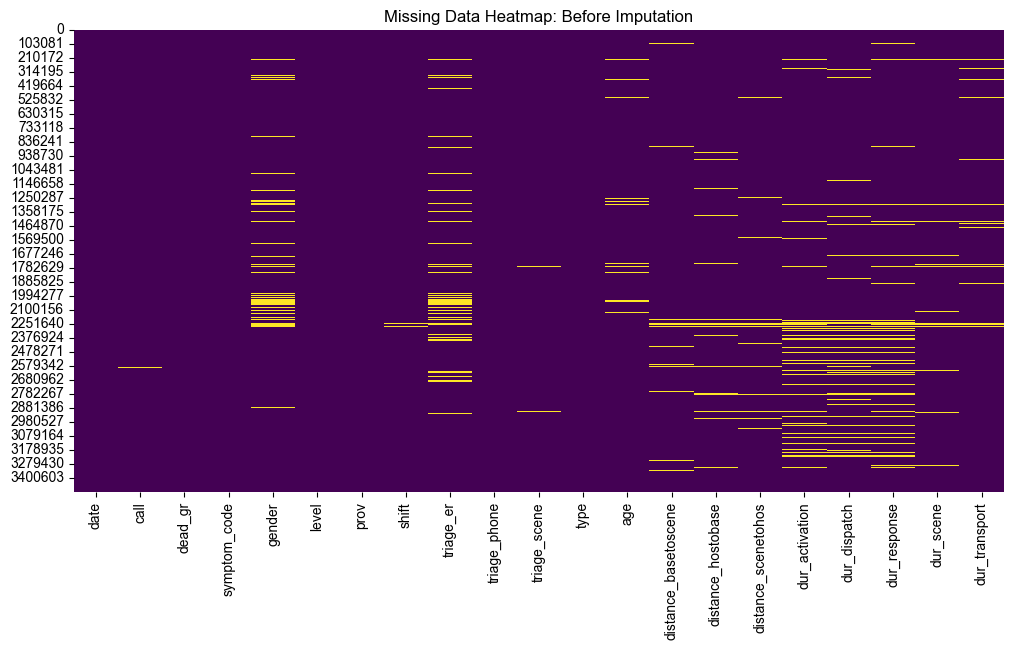

In [559]:
imputation.Missing.mcar(df_combined[primary_cols], alpha=0.05)
imputation.Missing.missing_visualize(df_combined[primary_cols], "Before Imputation")

Encoding...
Performing imputation...
Imputation successed.

── Data Summary ────────────────────────────────────────────────────────────────
Name                     : ITEMS (After Imputation)
Number of rows           : 3245545
Number of columns        : 26

── Pre-processing Data ─────────────────────────────────────────────────────────
Number of rows           : 3245545
Number of duplicated rows: 3491
Variable types:
   object              23
   float64             10
   datetime64[ns]      8
   bool                1

── Variable Types ──────────────────────────────────────────────────────────────
Number of rows : 3245545
Number of incomplete rows: 58444 (1.80%)
Variable types:
   object              16
   float64             10

── Variable type: object ───────────────────────────────────────────────────────
skim_variable      n_missing    complete_rate    n_unique  top_counts
---------------  -----------  ---------------  ----------  ------------------------------------------------

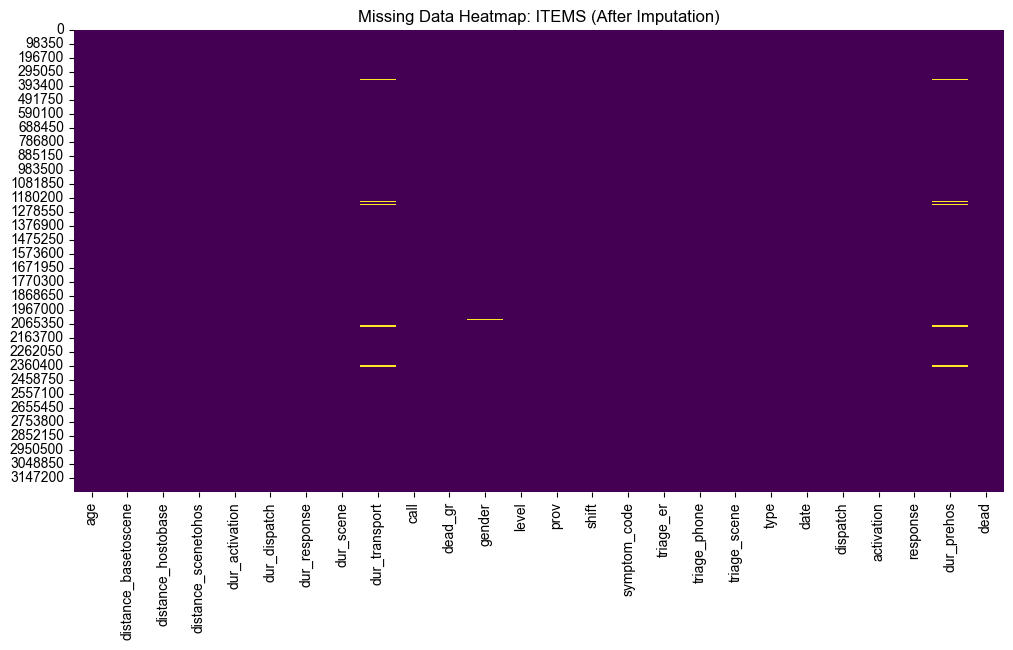

Creating dictionary: 100%|██████████| 26/26 [00:06<00:00,  3.82it/s]


Created data dictionary successfully: saved to output/clean/data_dict-ITEMS_imputed_MICE.xlsx


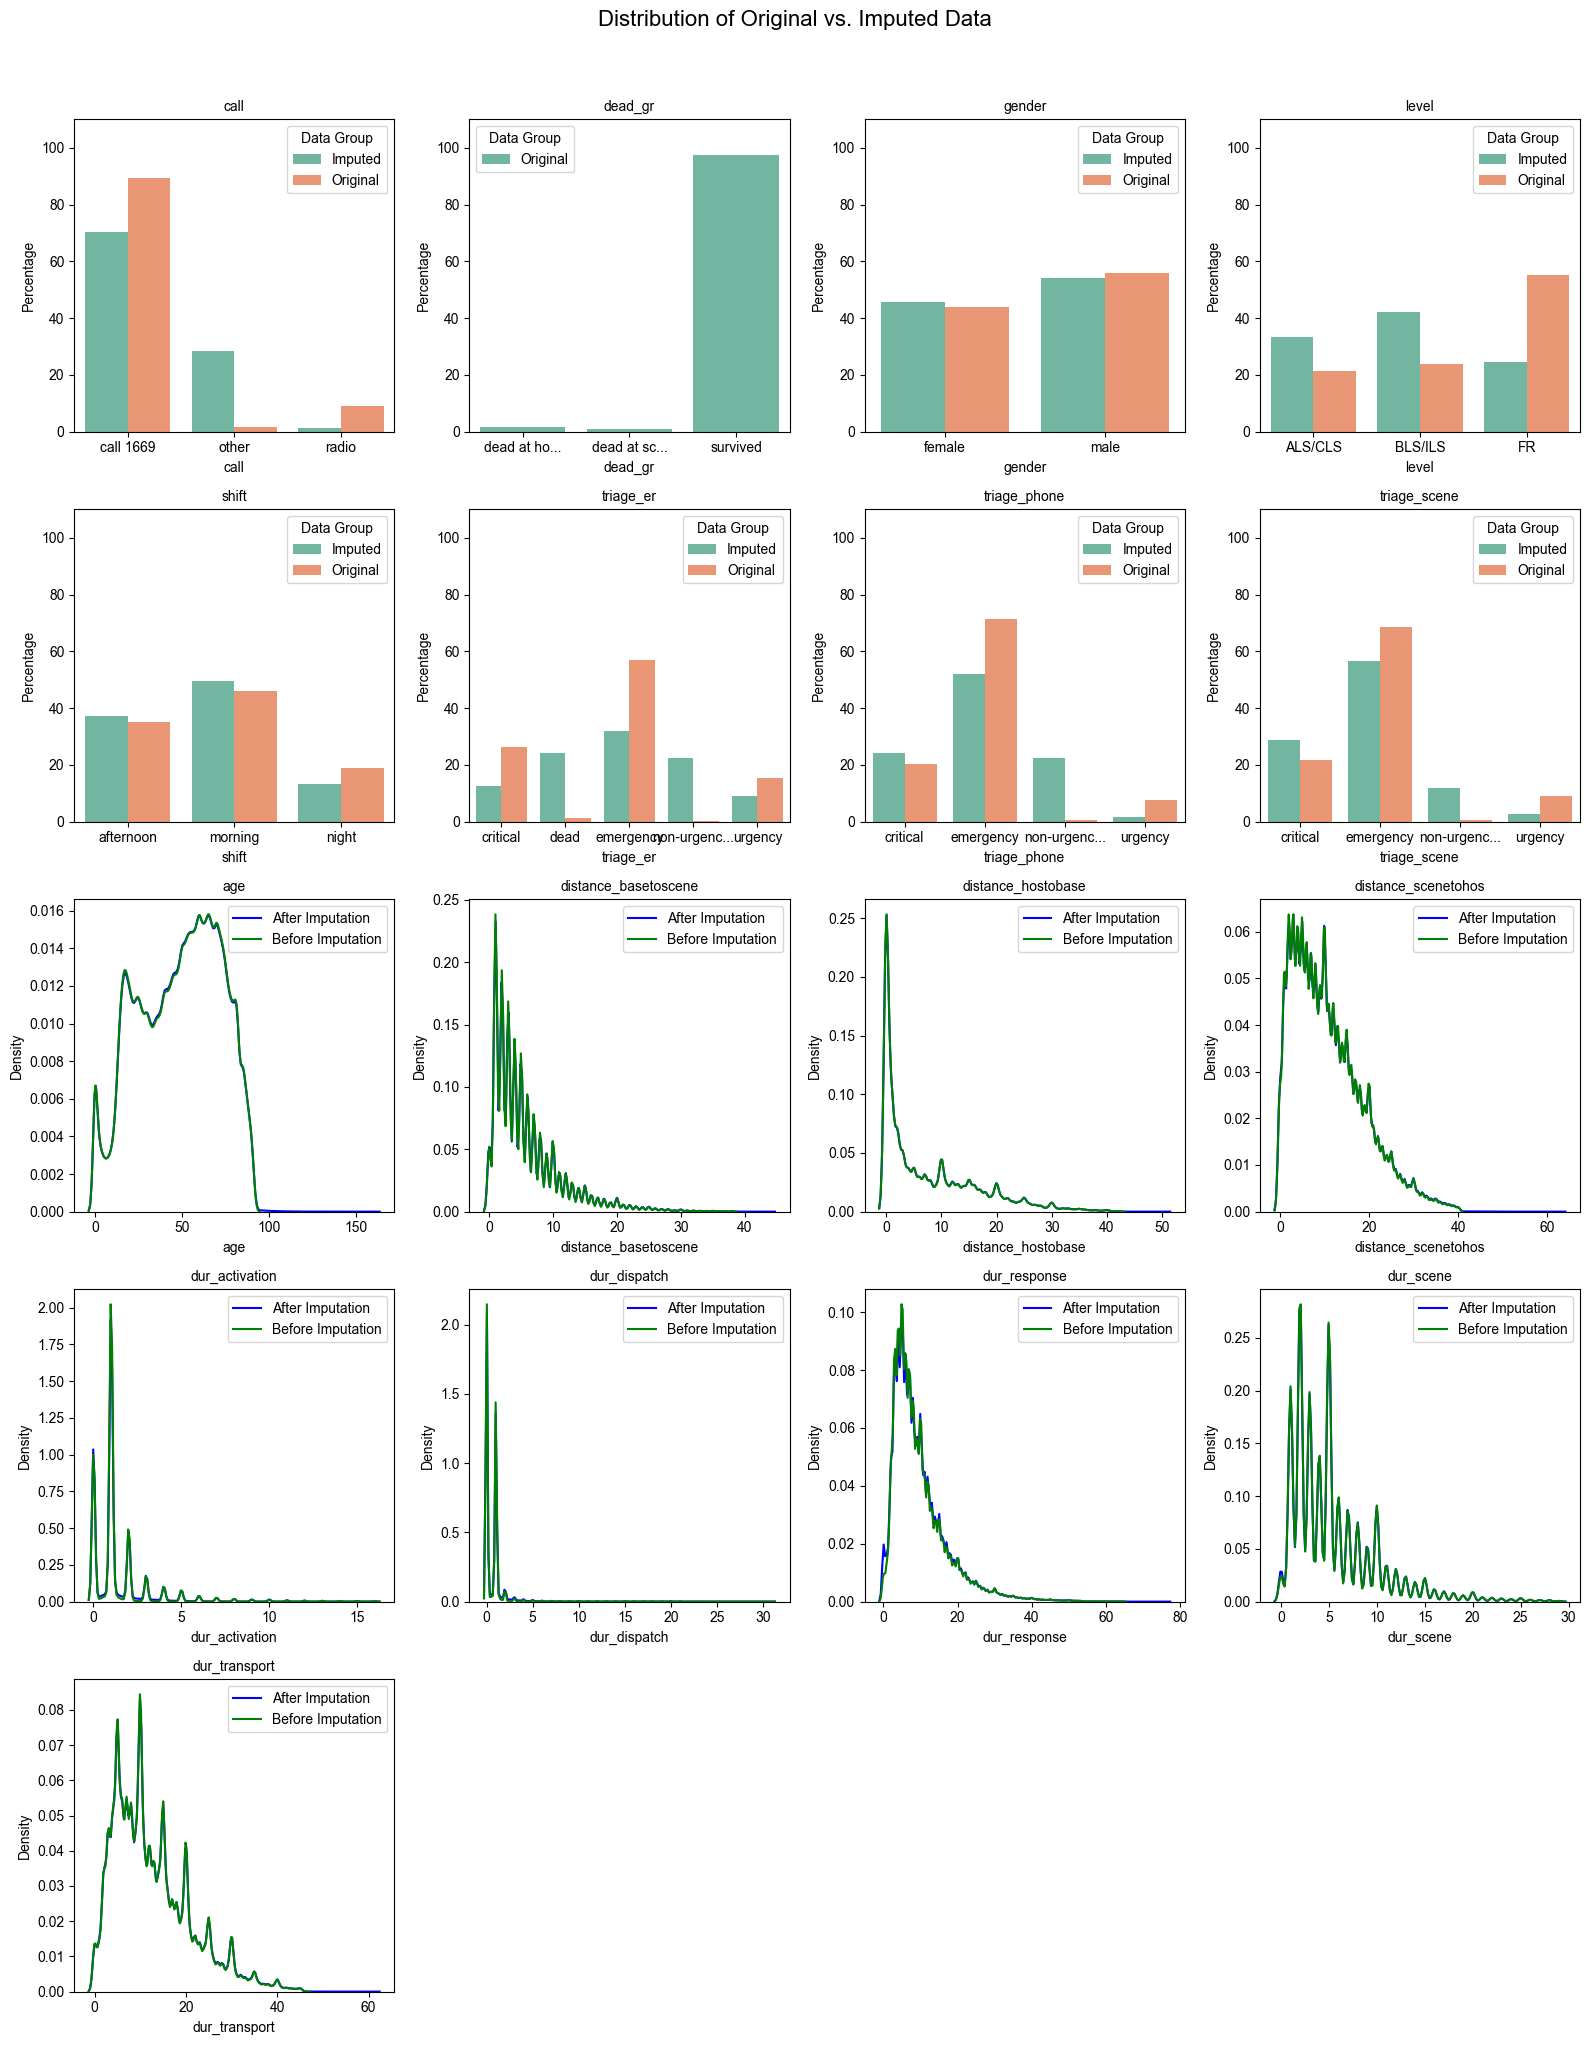

--- Effect Size for Numerical Variables ---
Variable                KS D-stat    Cohen's d
--------------------  -----------  -----------
age                          0            0
distance_basetoscene         0            0.01
distance_hostobase           0            0.01
distance_scenetohos          0            0.01
dur_activation               0.03         0.02
dur_dispatch                 0.04         0.04
dur_response                 0.01         0
dur_scene                    0.01         0
dur_transport              nan            0.01

--- Effect Size for Categorical Variables ---
Variable        Cramér's V
------------  ------------
call                  0
dead_gr               0
gender                0
level                 0
shift                 0
triage_er             0.07
triage_phone          0
triage_scene          0.01
type                  0


In [506]:
df_imputed = imputation.Imputation.imputation_mice(df_combined[primary_cols], inverse_transform=True, random_state=42, exclude_cols=['date'])

# Grouping the performance
numeric_cols = df_imputed.select_dtypes(include=['number']).columns
df_imputed[numeric_cols] = df_imputed[numeric_cols].clip(lower=0)
df_imputed.loc[df_imputed['dead_gr'] == 'dead at scene', 'dur_transport'] = np.nan

df_imputed['dispatch'] = df_imputed['dur_dispatch'].apply(
    lambda x: '<= 1 min' if pd.notna(x) and x <= 1 else
    '> 1 min' if pd.notna(x) and x > 1 else
    None
)
df_imputed['activation'] = df_imputed['dur_activation'].apply(
    lambda x: '<= 2 min' if pd.notna(x) and x <= 2 else
    '> 2 min' if pd.notna(x) and x > 2 else
    None
)
df_imputed['response'] = df_imputed['dur_response'].apply(
    lambda x: '<= 8' if pd.notna(x) and x <= 8 else
    '> 8' if pd.notna(x) and x > 8 else
    None
)
df_imputed['dur_prehos'] = df_imputed.apply(
    lambda row: row['dur_response'] + row['dur_scene'] + row['dur_transport']
    if pd.notna(row['dur_transport']) else np.nan,
    axis=1
)
df_imputed['dead'] = df_imputed['dead_gr'].apply(lambda x: 'survived' if x == 'survived' else 'dead' if pd.notna(x) else None)

skim.skim(df_imputed, df_combined, "ITEMS (After Imputation)")
imputation.Missing.missing_visualize(df_imputed, "ITEMS (After Imputation)")
df_imputed.to_csv('output/clean/ITEMS_imputed_MICE.csv')
dict_path = process.DataHandler.create_dictionary(df_imputed, 'ITEMS_imputed_MICE', 'output/clean')

imputation.Imputation.plot_imputation_comparison(df_combined, df_imputed, [col for col in primary_cols if col not in ['date', 'prov', 'symptom_code']])
imputation.Imputation.compare_imputation_statistics(df_combined, df_imputed, [col for col in primary_cols if col not in ['date', 'prov', 'symptom_code']], print_result=True)

# 3.Analyse
-------------------------------

In [534]:
file_name = 'ITEMS_imputed_MICE'
data_dir = 'output/clean'
output_dir = 'output/clean'

df, _, _ = process.DataCleaning.clean(file_name, data_dir, output_dir, clear=True, export_df=False)

df = df[df['symptom_code'] == '06:cardiac arrest']

prov_transfer_compare = ['Phrae', 'Lamphun', 'Maha Sarakham', 'Ubon Ratchathani', 'Sa Kaeo', 'Chumphon', 'Phatthalung', 'Songkhla'] #tranfers at least before October 2020
prov_nontransfer_compare = ['Mae Hong Son', 'Lampang', 'Khon Kaen', 'Mukdahan', 'Chon Buri', 'Phuket', 'Satun', 'Yala'] #compare provinces
df['transfer_compare'] = df['prov'].apply(lambda x:'yes' if x in prov_transfer_compare else 'no' if x in prov_nontransfer_compare else None)
df['monthyear'] = df['date'].apply(lambda x: str(x)[:7])

df['count'] = 'count'

df['response_10km'] = df.apply(
    lambda row: '<= 8' if (row['dur_response'] <= 8 and row['distance_basetoscene'] <= 10) else
                '> 8' if (row['dur_response'] > 8 and row['distance_basetoscene'] <= 10) else
                None, axis=1
)

df['gr_triage_phone'] = df['triage_phone'].apply(
    lambda x: 'non-emergent' if x in ['urgency', 'non-urgency'] else x
)

df['gr_triage_scene'] = df['triage_scene'].apply(
    lambda x: 'non-emergent' if x in ['urgency', 'non-urgency'] else x
)

df['gr_triage_er'] = df['triage_er'].apply(
    lambda x: 'non-emergent' if x in ['urgency', 'non-urgency'] else x
)

df['hregion'] = df['prov']
process.DataManipulation.mapping(df, 'hregion')

# Grouping the performance / Any from imputation
df['age_gr'] = df['age'].apply(
    lambda x: '>= 60 yr' if pd.notna(x) and x >= 60 else
    '< 60 yr' if pd.notna(x) else
    None
)
df['dispatch'] = df['dur_dispatch'].apply(
    lambda x: '<= 1 min' if pd.notna(x) and x <= 1 else
    '> 1 min' if pd.notna(x) and x > 1 else
    None
)
df['activation'] = df['dur_activation'].apply(
    lambda x: '<= 2 min' if pd.notna(x) and x <= 2 else
    '> 2 min' if pd.notna(x) and x > 2 else
    None
)
df['response'] = df['dur_response'].apply(
    lambda x: '<= 8 min' if pd.notna(x) and x <= 8 else
    '> 8 min' if pd.notna(x) and x > 8 else
    None
)

df['dead'] = df.apply(
    lambda row: ('dead' if row['dead_gr'] in ['dead at hos', 'dead at scene'] else 'survived'), axis=1)

df_foranalyse = df[~df['transfer_compare'].isna()].copy()
display(df_foranalyse.head())
print(f'Number of total cases: {len(df_foranalyse)}')
print(f'Number of transferred: {len(df_foranalyse[df_foranalyse['transfer_compare'] == 'yes'])}')
print(f'Number of non-transferred: {len(df_foranalyse[df_foranalyse['transfer_compare'] == 'no'])}')
print(f'Number of unique provinces: {len(df_foranalyse['prov'].unique())}')

File name                : ITEMS_imputed_MICE
Path to data dictionary  : output/clean/data_dict-ITEMS_imputed_MICE.xlsx
Path to cleaned dataset  : None


,Unnamed: 0,age,distance_basetoscene,distance_hostobase,distance_scenetohos,dur_activation,dur_dispatch,dur_response,dur_scene,dur_transport,call,dead_gr,gender,level,prov,shift,symptom_code,triage_er,triage_phone,triage_scene,type,date,dispatch,activation,response,dur_prehos,dead,transfer_compare,monthyear,count,response_10km,gr_triage_phone,gr_triage_scene,gr_triage_er,hregion,age_gr
642,642,107.273804,1.0,0.0,2.0,1.633333,0.333333,4.850000,5.183333,NaN,call 1669,dead at scene,male,ALS/CLS,Khon Kaen,night,06:cardiac arrest,dead,critical,critical,land,2022-11-23,<= 1 min,<= 2 min,<= 8 min,NaN,dead,no,2022-11,count,<= 8,critical,critical,dead,Health Region 7,>= 60 yr
824,824,77.000000,10.0,0.0,7.0,1.000000,0.000000,9.000000,7.433333,9.000000,call 1669,survived,male,ALS/CLS,Lampang,afternoon,06:cardiac arrest,critical,critical,critical,land,2022-11-23,<= 1 min,<= 2 min,> 8 min,25.433333,survived,no,2022-11,count,> 8,critical,critical,critical,Health Region 1,>= 60 yr
1406,1406,42.000000,6.0,0.0,6.0,0.500000,1.450000,9.550000,12.633333,11.000000,call 1669,survived,male,ALS/CLS,Khon Kaen,afternoon,06:cardiac arrest,critical,critical,critical,land,2021-10-01,> 1 min,<= 2 min,> 8 min,33.183333,survived,no,2021-10,count,> 8,critical,critical,critical,Health Region 7,< 60 yr
1834,1834,42.000000,7.0,22.0,22.0,0.933333,1.083333,10.083333,1.916667,43.166667,call 1669,survived,male,BLS/ILS,Khon Kaen,afternoon,06:cardiac arrest,critical,critical,critical,land,2021-10-01,> 1 min,<= 2 min,> 8 min,55.166667,survived,no,2021-10,count,> 8,critical,critical,critical,Health Region 7,< 60 yr
2017,2017,55.005715,3.0,0.0,3.0,4.000000,0.000000,9.000000,5.000000,NaN,call 1669,dead at scene,male,ALS/CLS,Songkhla,afternoon,06:cardiac arrest,dead,critical,critical,land,2021-10-01,<= 1 min,> 2 min,> 8 min,NaN,dead,yes,2021-10,count,> 8,critical,critical,dead,Health Region 12,< 60 yr


Number of total cases: 3749
Number of transferred: 1359
Number of non-transferred: 2390
Number of unique provinces: 16


In [547]:
file_name = 'ITEMS_combined'
data_dir = 'data/ITEMS/OVERALL'
output_dir = 'output/clean'

df, _, _ = process.DataCleaning.clean(file_name, data_dir, output_dir, clear=True, export_df=False)

df = df[df['symptom_code'] == '06:cardiac arrest']

prov_transfer_compare = ['Phrae', 'Lamphun', 'Maha Sarakham', 'Ubon Ratchathani', 'Sa Kaeo', 'Chumphon', 'Phatthalung', 'Songkhla'] #tranfers at least before October 2020
prov_nontransfer_compare = ['Mae Hong Son', 'Lampang', 'Khon Kaen', 'Mukdahan', 'Chon Buri', 'Phuket', 'Satun', 'Yala'] #compare provinces
df['transfer_compare'] = df['prov'].apply(lambda x:'yes' if x in prov_transfer_compare else 'no' if x in prov_nontransfer_compare else None)
df['monthyear'] = df['date'].apply(lambda x: str(x)[:7])

df['count'] = 'count'

df['response_10km'] = df.apply(
    lambda row: '<= 8' if (row['dur_response'] <= 8 and row['distance_basetoscene'] <= 10) else
                '> 8' if (row['dur_response'] > 8 and row['distance_basetoscene'] <= 10) else
                None, axis=1
)

df['gr_triage_phone'] = df['triage_phone'].apply(
    lambda x: 'non-emergent' if x in ['urgency', 'non-urgency'] else x
)

df['gr_triage_scene'] = df['triage_scene'].apply(
    lambda x: 'non-emergent' if x in ['urgency', 'non-urgency'] else x
)

df['gr_triage_er'] = df['triage_er'].apply(
    lambda x: 'non-emergent' if x in ['urgency', 'non-urgency'] else x
)

df['hregion'] = df['prov']
process.DataManipulation.mapping(df, 'hregion')

# Grouping the performance / Any from imputation
df['age_gr'] = df['age'].apply(
    lambda x: '>= 60 yr' if pd.notna(x) and x >= 60 else
    '< 60 yr' if pd.notna(x) else
    None
)
df['dispatch'] = df['dur_dispatch'].apply(
    lambda x: '<= 1 min' if pd.notna(x) and x <= 1 else
    '> 1 min' if pd.notna(x) and x > 1 else
    None
)
df['activation'] = df['dur_activation'].apply(
    lambda x: '<= 2 min' if pd.notna(x) and x <= 2 else
    '> 2 min' if pd.notna(x) and x > 2 else
    None
)
df['response'] = df['dur_response'].apply(
    lambda x: '<= 8 min' if pd.notna(x) and x <= 8 else
    '> 8 min' if pd.notna(x) and x > 8 else
    None
)

df['dead'] = df.apply(
    lambda row: ('dead' if row['dead_gr'] in ['dead at hos', 'dead at scene'] else 'survived'), axis=1)

df_original = df[~df['transfer_compare'].isna()].copy()
display(df_original.head())
print(f'Number of total cases: {len(df_original)}')
print(f'Number of transferred: {len(df_original[df_original['transfer_compare'] == 'yes'])}')
print(f'Number of non-transferred: {len(df_original[df_original['transfer_compare'] == 'no'])}')
print(f'Number of unique provinces: {len(df_original['prov'].unique())}')

File name                : ITEMS_combined
Path to data dictionary  : data/ITEMS/OVERALL/data_dict-ITEMS_combined.xlsx
Path to cleaned dataset  : None


,Unnamed: 0,time,shift,call,symptom_code,triage_phone,type,level,time_call,time_dispatch,time_outbase,time_arrive,time_scenedept,time_hosp,time_basereturn,distance_basetoscene,distance_scenetohos,distance_hostobase,triage_scene,result_op,gender,age,nationality,result_er,triage_er,admit,result_hos,dur_dispatch,dur_activation,dur_response,dur_scene,dur_transport,dur_prehos,prov,hosp_code,dead,dead_gr,dispatch,activation,response,source,missing,date,transfer_compare,monthyear,count,response_10km,gr_triage_phone,gr_triage_scene,gr_triage_er,hregion,age_gr
642,1348,2022-11-23 04:05:00,night,call 1669,06:cardiac arrest,critical,land,ALS/CLS,2022-11-23 04:05:00,2022-11-23 04:05:20,2022-11-23 04:06:58,2022-11-23 04:09:51,2022-11-23 04:15:02,2022-11-23 04:18:09,2022-11-23 04:18:09,1.0,2.0,0.0,critical,death at scene,NaN,NaN,NaN,dead,dead,dead,NaN,0.333333,1.633333,4.850000,5.183333,3.116667,13.150000,Khon Kaen,NaN,dead,dead at scene,<= 1 min,<= 2 min,<= 8 min,ITEMS,True,2022-11-23,no,2022-11,count,<= 8,critical,critical,dead,Health Region 7,None
824,1541,2022-11-23 21:49:34,afternoon,call 1669,06:cardiac arrest,critical,land,ALS/CLS,2022-11-23 21:49:34,2022-11-23 21:49:34,2022-11-23 21:50:34,2022-11-23 21:58:34,2022-11-23 22:06:00,2022-11-23 22:15:00,2022-11-23 22:15:00,10.0,7.0,0.0,critical,treat and transport,male,77.0,Thai,survived,critical,admit,survived,0.000000,1.000000,9.000000,7.433333,9.000000,25.433333,Lampang,10672.0,survived,survived,<= 1 min,<= 2 min,> 8 min,ITEMS,False,2022-11-23,no,2022-11,count,> 8,critical,critical,critical,Health Region 1,>= 60 yr
1406,2151,2021-10-01 17:38:25,afternoon,call 1669,06:cardiac arrest,critical,land,ALS/CLS,2021-10-01 17:38:25,2021-10-01 17:39:52,2021-10-01 17:40:22,2021-10-01 17:47:58,2021-10-01 18:00:36,2021-10-01 18:11:36,2021-10-01 18:11:36,6.0,6.0,0.0,critical,treat and transport,male,42.0,Thai,survived,critical,admit,survived,1.450000,0.500000,9.550000,12.633333,11.000000,33.183333,Khon Kaen,13777.0,survived,survived,> 1 min,<= 2 min,> 8 min,ITEMS,False,2021-10-01,no,2021-10,count,> 8,critical,critical,critical,Health Region 7,< 60 yr
1834,2599,2021-10-01 17:17:35,afternoon,call 1669,06:cardiac arrest,critical,land,BLS/ILS,2021-10-01 17:17:35,2021-10-01 17:18:40,2021-10-01 17:19:36,2021-10-01 17:27:40,2021-10-01 17:29:35,2021-10-01 18:12:45,2021-10-01 19:00:36,7.0,22.0,22.0,critical,treat and transport,male,42.0,Thai,survived,critical,NaN,NaN,1.083333,0.933333,10.083333,1.916667,43.166667,55.166667,Khon Kaen,13777.0,survived,survived,> 1 min,<= 2 min,> 8 min,ITEMS,True,2021-10-01,no,2021-10,count,> 8,critical,critical,critical,Health Region 7,< 60 yr
2017,2792,2021-10-01 17:44:45,afternoon,call 1669,06:cardiac arrest,critical,land,ALS/CLS,2021-10-01 18:00:00,2021-10-01 18:00:00,2021-10-01 18:04:00,2021-10-01 18:09:00,2021-10-01 18:14:00,2021-10-01 18:19:00,2021-10-01 18:19:00,3.0,3.0,0.0,NaN,death at scene,NaN,NaN,NaN,NaN,dead,dead,NaN,0.000000,4.000000,9.000000,5.000000,5.000000,19.000000,Songkhla,NaN,dead,dead at scene,<= 1 min,> 2 min,> 8 min,ITEMS,True,2021-10-01,yes,2021-10,count,> 8,critical,NaN,dead,Health Region 12,None


Number of total cases: 3744
Number of transferred: 1357
Number of non-transferred: 2387
Number of unique provinces: 16


In [512]:
# Count the number of cases per month per province
cases_per_month = df_foranalyse.groupby(['prov', 'monthyear']).size().reset_index(name='case_count')

overall_stats = cases_per_month['case_count'].agg(
    median_cases='median',  # P50 (Median)
    p25_cases=lambda x: x.quantile(0.25),
    p75_cases=lambda x: x.quantile(0.75)
)

# Compute the average number of cases per month for each province
avg_cases_per_province = cases_per_month.groupby('prov')['case_count'].agg(
    avg_cases_per_month='median',  # P50 (Median)
    p25=lambda x: x.quantile(0.25),
    p75=lambda x: x.quantile(0.75)
).reset_index()
avg_cases_per_province['transfer_compare'] = avg_cases_per_province['prov'].apply(lambda x:'yes' if x in prov_transfer_compare else 'no')

# Compute the median, P25, and P75 per group
avg_cases_per_group = avg_cases_per_province.groupby('transfer_compare').agg(
    median_cases=('avg_cases_per_month', 'median'),
    p25_cases=('avg_cases_per_month', lambda x: x.quantile(0.25)),
    p75_cases=('avg_cases_per_month', lambda x: x.quantile(0.75))
).reset_index()

display(overall_stats)
display(avg_cases_per_group)

median_cases     6.0
p25_cases        2.0
p75_cases       17.0
Name: case_count, dtype: float64

,transfer_compare,median_cases,p25_cases,p75_cases
0,no,4.5,1.750,15.875
1,yes,6.5,1.875,12.000


In [513]:
group_by = 'transfer_compare'
df = df_foranalyse.copy()

table_name = '01_characteristics'
parameters = ['gender', 'age', 'call', 'shift', 'triage_phone', 'triage_scene', 'triage_er']
analyse.Descriptive.describe(df, parameters, group_by, overall=True, table_name=table_name, export_result=True)

table_name = '02_performance'
parameters = ['level', 'dur_dispatch', 'dur_activation', 'dur_response', 'dur_scene', 'dur_transport', 'dur_prehos', 'dead_gr']
analyse.Descriptive.describe(df, parameters, group_by, overall=True, table_name=table_name, export_result=True)

01_characteristics
Analysis of age using Mann-Whitney U Test
Characteristics    Total          no             yes            P-value    Effect Size    Interpretation
-----------------  -------------  -------------  -------------  ---------  -------------  ----------------
gender                                                          0.99       0.00           Negligible
female             1,319          841            478
                   (35.41%)       (35.38%)       (35.46%)
male               2,406          1,536          870
                   (64.59%)       (64.62%)       (64.54%)
age                60.62          60.00          61.00          0.03       0.04           Negligible
                   (46.00-73.00)  (44.00-72.91)  (47.00-73.17)
call                                                            0.00       0.09           Negligible
call 1669          3,365          2,102          1,263
                   (89.76%)       (87.95%)       (92.94%)
other              50     

In [514]:
group_by = 'prov'
df = df_foranalyse.copy()

table_name = '03_Mortality'
parameters = ['count', 'dead_gr']
analyse.Descriptive.describe(df, parameters, group_by, overall=True, table_name=table_name, export_result=True)

03_Mortality
Characteristics    Total      Khon Kaen    Lampang    Songkhla    Chumphon    Sa Kaeo    Chon Buri    Phrae      Yala       Phuket     Maha Sarakham    Lamphun    Phatthalung    Satun      Mukdahan    Mae Hong Son    Ubon Ratchathani    P-value    Effect Size    Interpretation
-----------------  ---------  -----------  ---------  ----------  ----------  ---------  -----------  ---------  ---------  ---------  ---------------  ---------  -------------  ---------  ----------  --------------  ------------------  ---------  -------------  ----------------
count                                                                                                                                                                                                                                        1.00       nan            Large
count              3,749      994          77         421         316         253        960          33         119        170        253              34      

/Users/p.sitthirat/Desktop/HPSR_QUANTI/Prehos/scripts/analyse.py:415: RuntimeWarning: invalid value encountered in divide
  effect_size = np.sqrt(chi2_stat / (n * min_dim))


In [555]:
df = df_foranalyse.copy()
outcome = 'dead_gr'
predictors = ['transfer_compare', 'gender', 'age_gr', 'shift', 'call', 'level', 'dur_activation', 'dur_dispatch', 'dur_response', 'dur_scene', 'distance_basetoscene']
col_selected = predictors + [outcome]

reference_group = {
    'gender': 'male',
    'shift': 'morning',
    'call': 'call 1669',
    'triage_scene': 'urgency',
    'triage_er': 'urgency',
    'gr_triage_phone': 'non-emergent',
    'gr_triage_scene': 'non-emergent',
    'gr_triage_er': 'non-emergent',
    'level': 'FR',
    'perform_scene': 'accurate',
    'perform_er': 'accurate',
    'activation': '<= 2 min',
    'dispatch': '<= 1 min',
    'response': '<= 8 min',
    'transfer': 'no',
    'hregion': 'Health Region 1',
    'symptom_code': '06:cardiac arrest',
    'age_gr': '< 60 yr'
}

logis_df = analyse.Regression.logistic(df, independent_var=predictors, dependent_var=outcome, independent_assign=reference_group, dependent_assign=['survived', 'dead at hos', 'dead at scene'], export_result=True, table_name='03_MNLogisticRegression')
logis_df_sens = analyse.Regression.logistic(df_original[col_selected].dropna(), independent_var=predictors, dependent_var=outcome, independent_assign=reference_group, dependent_assign=['survived', 'dead at hos', 'dead at scene'], export_result=True, table_name='03_MNLogisticRegression_Sensitivity')

,dead_gr,transfer_compare,gender,age_gr,shift,call,level,dur_activation,dur_dispatch,dur_response,dur_scene,distance_basetoscene
642,dead at scene,no,male,>= 60 yr,night,call 1669,ALS/CLS,1.633333,0.333333,4.850000,5.183333,1.0
824,survived,no,male,>= 60 yr,afternoon,call 1669,ALS/CLS,1.000000,0.000000,9.000000,7.433333,10.0
1406,survived,no,male,< 60 yr,afternoon,call 1669,ALS/CLS,0.500000,1.450000,9.550000,12.633333,6.0
1834,survived,no,male,< 60 yr,afternoon,call 1669,BLS/ILS,0.933333,1.083333,10.083333,1.916667,7.0
2017,dead at scene,yes,male,< 60 yr,afternoon,call 1669,ALS/CLS,4.000000,0.000000,9.000000,5.000000,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...
3244743,survived,no,male,< 60 yr,afternoon,call 1669,ALS/CLS,1.000000,0.000000,15.000000,14.000000,12.0
3244795,dead at scene,no,female,< 60 yr,morning,call 1669,BLS/ILS,3.000000,2.000000,10.000000,3.286190,4.0
3244796,dead at scene,no,female,< 60 yr,morning,call 1669,ALS/CLS,4.000000,0.000000,13.000000,13.000000,4.0
3245074,dead at scene,no,female,>= 60 yr,night,call 1669,ALS/CLS,0.083333,0.916667,8.000000,9.000000,3.0


3713

No multicollinearity detected (all VIF values ≤ 5).

Multinomial Logistic Regression:
Pseudo R-squ.: 0.06
Log-Likelihood: -3789.23
LL-Null: -4029.45
LLR p-value: 0.00
outcome        predictor                                                coef (log OR)     OR    P>|z|    [0.025    0.975]
-------------  -----------------------------------------------------  ---------------  -----  -------  --------  --------
dead at hos    C(age_gr, Treatment(reference='< 60 yr'))[T.>= 60 yr]           -0.182  0.834    0.043     0.699     0.994
dead at hos    C(call, Treatment(reference='call 1669'))[T.other]               0.808  2.243    0.043     1.025     4.907
dead at hos    C(call, Treatment(reference='call 1669'))[T.radio]               0.394  1.483    0.013     1.085     2.027
dead at hos    C(gender, Treatment(reference='male'))[T.female]                -0.194  0.824    0.042     0.683     0.993
dead at hos    C(level, Treatment(reference='FR'))[T.ALS/CLS]                   1.028  2.795    0    

,dead_gr,transfer_compare,gender,age_gr,shift,call,level,dur_activation,dur_dispatch,dur_response,dur_scene,distance_basetoscene
824,survived,no,male,>= 60 yr,afternoon,call 1669,ALS/CLS,1.000000,0.000000,9.000000,7.433333,10.0
1406,survived,no,male,< 60 yr,afternoon,call 1669,ALS/CLS,0.500000,1.450000,9.550000,12.633333,6.0
1834,survived,no,male,< 60 yr,afternoon,call 1669,BLS/ILS,0.933333,1.083333,10.083333,1.916667,7.0
10540,survived,yes,male,< 60 yr,morning,call 1669,ALS/CLS,1.000000,2.000000,11.000000,2.000000,8.0
10887,survived,no,male,< 60 yr,morning,call 1669,FR,1.300000,1.600000,13.066667,3.033333,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...
3244660,dead at scene,no,male,< 60 yr,afternoon,call 1669,BLS/ILS,3.000000,2.000000,9.000000,28.000000,2.0
3244661,dead at scene,no,male,< 60 yr,afternoon,call 1669,ALS/CLS,2.000000,3.000000,15.000000,13.000000,7.0
3244743,survived,no,male,< 60 yr,afternoon,call 1669,ALS/CLS,1.000000,0.000000,15.000000,14.000000,12.0
3244796,dead at scene,no,female,< 60 yr,morning,call 1669,ALS/CLS,4.000000,0.000000,13.000000,13.000000,4.0


2359

No multicollinearity detected (all VIF values ≤ 5).

Multinomial Logistic Regression:
Pseudo R-squ.: 0.11
Log-Likelihood: -2257.64
LL-Null: -2538.92
LLR p-value: 0.00
outcome        predictor                                                coef (log OR)     OR    P>|z|    [0.025    0.975]
-------------  -----------------------------------------------------  ---------------  -----  -------  --------  --------
dead at hos    C(age_gr, Treatment(reference='< 60 yr'))[T.>= 60 yr]           -0.174  0.84     0.1       0.682     1.034
dead at hos    C(call, Treatment(reference='call 1669'))[T.other]               0.96   2.612    0.06      0.962     7.091
dead at hos    C(call, Treatment(reference='call 1669'))[T.radio]               0.428  1.534    0.029     1.044     2.256
dead at hos    C(gender, Treatment(reference='male'))[T.female]                -0.106  0.899    0.347     0.721     1.122
dead at hos    C(level, Treatment(reference='FR'))[T.ALS/CLS]                   1.023  2.782    0    

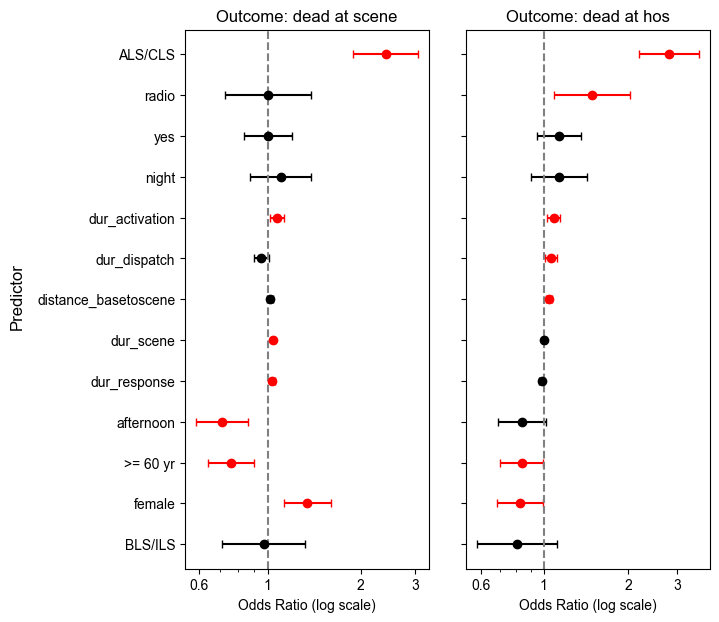

In [553]:
# Sort for cleaner plotting
df = logis_df.copy()
df.sort_values(by=["outcome", "OR"], ascending=[True, False], inplace=True)
df['predictor_extracted'] = df['predictor'].apply(
    lambda x: pd.Series(x).str.extract(r'\[T\.(.+?)\]').fillna(x).iloc[0]
)

predictors = df['predictor_extracted'].unique()[::-1]
predictors = [p for p in predictors if p not in ['Intercept', 'other']]
y = np.arange(len(predictors))
predictor_to_y = {label: idx for idx, label in enumerate(predictors)}
significance_threshold = 0.05

# Redraw the forest plot with highlighted significant predictors
fig, axes = plt.subplots(1, 2, figsize=(7, 7), sharey=True)
outcomes = ['dead at scene', 'dead at hos']
colors = {'dead at hos': 'black', 'dead at scene': 'black'}

for i, outcome in enumerate(outcomes):
    ax = axes[i]
    sub = df[df['outcome'] == outcome]
    sub = sub[sub['predictor_extracted'].isin(predictors)]

    y_vals = sub['predictor_extracted'].map(predictor_to_y)
    or_vals = sub['OR']
    lower = sub['[0.025']
    upper = sub['0.975]']
    pvals = sub['P>|z|']
    is_sig = pvals < significance_threshold

    # Highlight significant predictors with a star marker
    ax.errorbar(
        or_vals[~is_sig],
        y_vals[~is_sig],
        xerr=[np.abs(or_vals[~is_sig] - lower[~is_sig]), np.abs(upper[~is_sig] - or_vals[~is_sig])],
        fmt='o',
        color=colors[outcome],
        capsize=3
    )

    ax.errorbar(
        or_vals[is_sig],
        y_vals[is_sig],
        xerr=[np.abs(or_vals[is_sig] - lower[is_sig]), np.abs(upper[is_sig] - or_vals[is_sig])],
        fmt='ro',
        capsize=3,
        label='p < 0.05' if i == 0 else ""
    )

    ax.axvline(1, linestyle='--', color='gray')
    ax.set_xscale('log')
    ax.set_xticks([0.6, 1, 2, 3])
    ax.set_xticklabels(['0.6', '1', '2', '3'])
    ax.set_title(f'Outcome: {outcome}')
    ax.set_xlabel("Odds Ratio (log scale)")
    # ax.set_xlim(0.5,4)

    if i == 1:
        ax.set_yticks(y)
        ax.set_yticklabels(predictors, fontsize=10)
    else:
        ax.set_yticks(y)
        ax.set_yticklabels([])

# Add legend and adjust layout
fig.text(-0.1, 0.5, 'Predictor', va='center', rotation='vertical', fontsize=12)
plt.subplots_adjust(left=0.15, wspace=0.15)
plt.show()


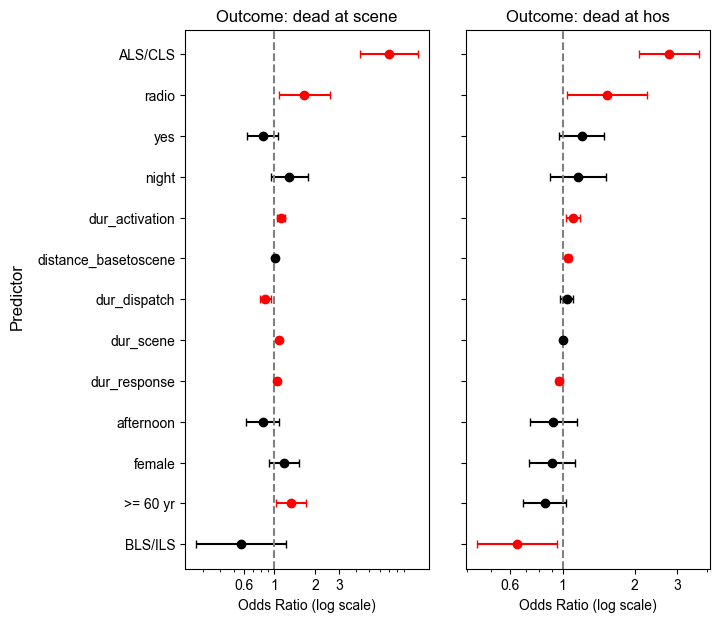

In [554]:
# Sort for cleaner plotting
df = logis_df_sens.copy()
df.sort_values(by=["outcome", "OR"], ascending=[True, False], inplace=True)
df['predictor_extracted'] = df['predictor'].apply(
    lambda x: pd.Series(x).str.extract(r'\[T\.(.+?)\]').fillna(x).iloc[0]
)

predictors = df['predictor_extracted'].unique()[::-1]
predictors = [p for p in predictors if p not in ['Intercept', 'other']]
y = np.arange(len(predictors))
predictor_to_y = {label: idx for idx, label in enumerate(predictors)}
significance_threshold = 0.05

# Redraw the forest plot with highlighted significant predictors
fig, axes = plt.subplots(1, 2, figsize=(7, 7), sharey=True)
outcomes = ['dead at scene', 'dead at hos']
colors = {'dead at hos': 'black', 'dead at scene': 'black'}

for i, outcome in enumerate(outcomes):
    ax = axes[i]
    sub = df[df['outcome'] == outcome]
    sub = sub[sub['predictor_extracted'].isin(predictors)]

    y_vals = sub['predictor_extracted'].map(predictor_to_y)
    or_vals = sub['OR']
    lower = sub['[0.025']
    upper = sub['0.975]']
    pvals = sub['P>|z|']
    is_sig = pvals < significance_threshold

    # Highlight significant predictors with a star marker
    ax.errorbar(
        or_vals[~is_sig],
        y_vals[~is_sig],
        xerr=[np.abs(or_vals[~is_sig] - lower[~is_sig]), np.abs(upper[~is_sig] - or_vals[~is_sig])],
        fmt='o',
        color=colors[outcome],
        capsize=3
    )

    ax.errorbar(
        or_vals[is_sig],
        y_vals[is_sig],
        xerr=[np.abs(or_vals[is_sig] - lower[is_sig]), np.abs(upper[is_sig] - or_vals[is_sig])],
        fmt='ro',
        capsize=3,
        label='p < 0.05' if i == 0 else ""
    )

    ax.axvline(1, linestyle='--', color='gray')
    ax.set_xscale('log')
    ax.set_xticks([0.6, 1, 2, 3])
    ax.set_xticklabels(['0.6', '1', '2', '3'])
    ax.set_title(f'Outcome: {outcome}')
    ax.set_xlabel("Odds Ratio (log scale)")
    # ax.set_xlim(0.5,4)

    if i == 1:
        ax.set_yticks(y)
        ax.set_yticklabels(predictors, fontsize=10)
    else:
        ax.set_yticks(y)
        ax.set_yticklabels([])

# Add legend and adjust layout
fig.text(-0.1, 0.5, 'Predictor', va='center', rotation='vertical', fontsize=12)
plt.subplots_adjust(left=0.15, wspace=0.15)
plt.show()
